This notebook analyzes the UCI Bank Marketing dataset to predict customer subscription to term deposits. Using 45,211 records from Portuguese bank marketing campaigns, we implement and compare three classification models: K-Nearest Neighbors (KNN), Logistic Regression, and Random Forest. The analysis addresses key challenges like data leakage by removing the 'duration' feature to ensure realistic predictions. Model performance is evaluated using accuracy, precision, recall, and confusion matrices to identify the most effective approach for targeting potential subscribers and optimizing marketing campaign efficiency.

In [5]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, roc_curve


In [6]:
#set random seed for reproducibility
np.random.seed(42)

In [7]:
df = pd.read_csv("../../data/raw/bank-full.csv", sep=";")

**1. Data Exploration and Preprocessing**

In [8]:
df.info() #45211 entries, 17 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [9]:
df.head() #display the first 5 rows

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [10]:
# calculate the percentage and count of the two categories of the y variable
100 * df.groupby("y").size() / df.shape[0]

y
no     88.30152
yes    11.69848
dtype: float64

In [11]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

All columns show 0 missing values. The UCI Bank Marketing dataset is pre-cleaned. Categorical variables use "unknown" as a category instead of NULL. Numerical variables have actual values or defaults

In [12]:
# check missing values in the dataset
df.isnull().sum()


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

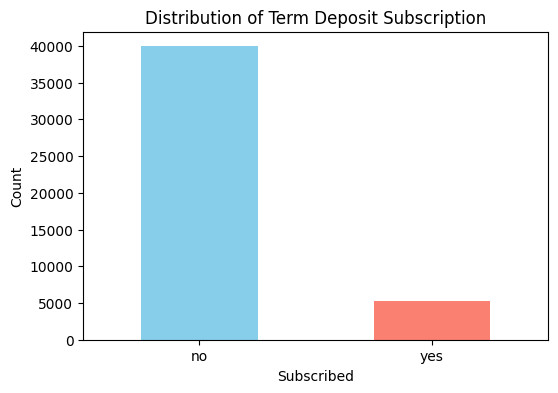

In [13]:
# Visualize target distribution with a bar chart
plt.figure(figsize=(6, 4))  # Create a figure of size 6x4 inches
df['y'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])  # Create bar plot
plt.title('Distribution of Term Deposit Subscription')  # Add title
plt.xlabel('Subscribed')  # Label x-axis
plt.ylabel('Count')  # Label y-axis
plt.xticks(rotation=0)  # Don't rotate the x-axis labels
plt.show() 

**2. Feature Analysis and Encoding**

In [35]:
# Separate features (X) from target variable (y)
# X contains all input variables, y contains what we want to predict
X = df.drop('y', axis=1)  # remove 'y' column from features
y = df['y']  # target variable - what we want to predict


In [36]:
#identify which columns are categorical and numerical
categorical_cols = X.select_dtypes(include=['object']).columns.tolist() 
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numerical columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [55]:
#convert categorical text data into numbers
label_encoders = {}
X_encoded = X.copy()

#loop through each categorical column and convert text to numbers
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col]=le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le

In [56]:
# encode target variable to 1/0. 'yes' becomes 1, 'no' becomes 0
y_encoded=(y == 'yes').astype(int)


In [57]:
X_encoded.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3


**3. Handle Data Leakage: remove 'duration' for realistic prediction**

In the dataset, the *duration* feature is a classic example of data leakage. The *duration* feature is highly correlated with the term deposit subscription - longer calls usually mean more deposit. In a real-world scenario, we don't know how long a call will last **before** making the call. In this case, duration is removed in creating prediction models. 

In [58]:
X_features = X_encoded.drop('duration', axis=1)
numerical_cols = [col for col in numerical_cols if col != 'duration']
X_features.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'campaign',
 'pdays',
 'previous',
 'poutcome']

**4. Scale Data**

By standardizing our features in the dataset, to make sure they are on the same scale. As we've seen, differences in scale can disproportionately affect machine learning models that rely on distance metrics (e.g., K-Nearest Neighbors). 

In [59]:
# Initialize the StandardScaler to standardize the selected numeric columns
scaler = StandardScaler()

X_features[numerical_cols] = scaler.fit_transform(X_features[numerical_cols])
X_features.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome
0,1.606965,4,1,2,0,0.256419,1,0,2,-1.298476,8,-0.569351,-0.411453,-0.25194,3
1,0.288529,9,2,1,0,-0.437895,1,0,2,-1.298476,8,-0.569351,-0.411453,-0.25194,3
2,-0.747384,2,1,1,0,-0.446762,1,1,2,-1.298476,8,-0.569351,-0.411453,-0.25194,3
3,0.571051,1,1,3,0,0.047205,1,0,2,-1.298476,8,-0.569351,-0.411453,-0.25194,3
4,-0.747384,11,2,3,0,-0.447091,0,0,2,-1.298476,8,-0.569351,-0.411453,-0.25194,3


**5. Split data into training and test sets**

Split 75% of the data for training—so the model has enough information to learn patterns—and 25% for testing, to ensure a reliable measure of its performance on unseen cases.


In [60]:
X_train, X_test, y_train, y_test = train_test_split(X_features, y_encoded, train_size=0.75, stratify=y_encoded, random_state=42)

In [61]:
X_train.shape

(33908, 15)

In [62]:
X_test.shape

(11303, 15)

In [63]:
y_train.shape

(33908,)

In [64]:
y_test.shape

(11303,)

**6. Build and evaluate multiple models**

**6.1 K-Nearest Neighbors**

In [65]:
# KNeighborsClassifier looks at the 'k' closest data points to make predictions
# n_neighbors=5 means it looks at the 5 most similar customers
knn = KNeighborsClassifier(n_neighbors=5)

In [66]:
# Train the model
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [67]:
# make prediction
y_pred = knn.predict(X_test)               
y_pred_proba = knn.predict_proba(X_test)[:, 1]

In [68]:
# calculate accuracy score: % of correct predictions
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8862248960452977

In [69]:
# precision score: Of customers we predicted would subscribe, how many actually did? 
precision = precision_score(y_test, y_pred)
precision

0.5350194552529183

In [70]:
# Recall: Of customers who actually subscribed, how many did we catch?
recall = recall_score(y_test, y_pred)
recall

0.20801815431164902

In [71]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[9742,  239],
       [1047,  275]])

In [75]:
# find the best k value
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31, 51]
accuracies = []
precisions = []
recalls = []


for k in k_values:
    # Create and train KNN with current k
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    y_pred_k = knn_k.predict(X_test)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred_k)
    prec = precision_score(y_test, y_pred_k)
    rec = recall_score(y_test, y_pred_k)
    
    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    
    print(f"{k:<5} {acc:<12.2%} {prec:<12.2%} {rec:<12.2%}")
    
# Find best k based on accuracy
best_k_idx = accuracies.index(max(accuracies))
best_k = k_values[best_k_idx]

print(f"\n best k value: k={best_k} (Accuracy: {accuracies[best_k_idx]:.2%})")

1     84.02%       30.26%       28.06%      
3     88.00%       47.43%       23.75%      
5     88.62%       53.50%       20.80%      
7     88.86%       57.18%       18.99%      
9     89.11%       61.46%       18.46%      
11    89.00%       61.06%       16.49%      
15    88.95%       62.29%       13.99%      
21    88.99%       66.81%       11.72%      
31    88.94%       70.45%       9.38%       
51    88.81%       77.67%       6.05%       

 best k value: k=9 (Accuracy: 89.11%)


In [76]:
# final model with best k
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)
y_pred_final = best_knn.predict(X_test)

final_acc = accuracy_score(y_test, y_pred_final)
final_prec = precision_score(y_test, y_pred_final)
final_rec = recall_score(y_test, y_pred_final)
print(final_acc,final_prec,final_rec)

0.891090860833407 0.6146095717884131 0.18456883509833585


The final model suggests that:

<br> If we call 100 customers the model predicts will subscribe:
   <br>About 61 will actually subscribe (precision)
   <br>About 39 calls are wasted
   
 <br> Out of 100 actual subscribers:
   <br> The model will find about 18 of them (recall)
   <br> About 82 will be missed

Overall, the model is correct 89% of the time


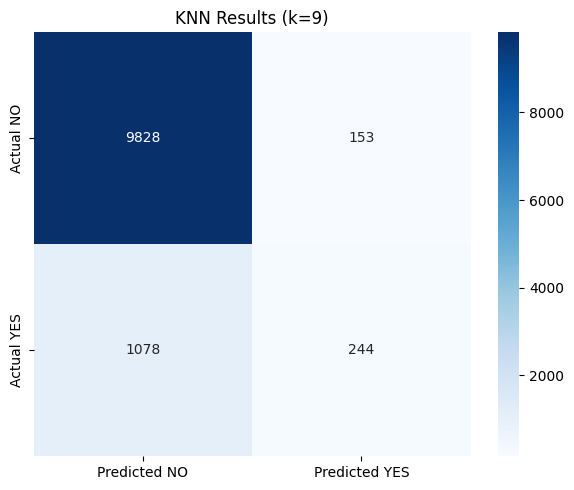

In [78]:
#confusion matrix
cm_KNN= confusion_matrix(y_test, y_pred_final)
cm_KNN

plt.figure(figsize=(6, 5))
sns.heatmap(cm_KNN, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted NO', 'Predicted YES'],
            yticklabels=['Actual NO', 'Actual YES'])
plt.title(f'KNN Results (k=9)')
plt.tight_layout()
plt.show()

The confusion matrix tells us that: 
> 9828 customers correctly predicted as non-subscribers

> 153 customers predicted YES but actually said NO

> 1078 customers predicted NO but actually subscribed

> 244 customers correctly predicted as subscribers

**6.2 Logistic Regression Model**

In [79]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

accuracy_log=accuracy_score(y_test, y_pred)
precision_log=precision_score(y_test, y_pred)
recall_log=recall_score(y_test, y_pred)

print(accuracy_log,precision_log,recall_log)

0.883128372998319 0.5172413793103449 0.0113464447806354


In [81]:
# find the best C
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
best_accuracy = 0
best_model = None

for C in C_values:
    # Train model
    model = LogisticRegression(C=C, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy_log = accuracy_score(y_test, y_pred)
    precision_log = precision_score(y_test, y_pred)
    recall_log = recall_score(y_test, y_pred)
    
    print(f"{C:7}  |   {accuracy_log:.2%}    |   {precision_log:.2%}    |   {recall_log:.2%}")
    
    # Save best model
    if accuracy_log > best_accuracy:
        best_accuracy = accuracy_log
        best_model = model
        best_C = C
        best_predictions = y_pred

print(f"\n Best C = {best_C} with accuracy = {best_accuracy:.2%}")
print(f"accuracy_log = {accuracy_log:.2%}")
print(f"precision_log = {precision_log:.2%}")
print(f"recall_log = {recall_log:.2%}")


# Use best model for final predictions
y_pred_best = best_model.predict(X_test)


  0.001  |   88.30%    |   50.00%    |   0.15%
   0.01  |   88.33%    |   60.00%    |   0.68%
    0.1  |   88.34%    |   57.69%    |   1.13%
      1  |   88.31%    |   51.72%    |   1.13%
     10  |   88.32%    |   53.57%    |   1.13%
    100  |   88.32%    |   53.57%    |   1.13%

 Best C = 0.1 with accuracy = 88.34%
accuracy_log = 88.32%
precision_log = 53.57%
recall_log = 1.13%


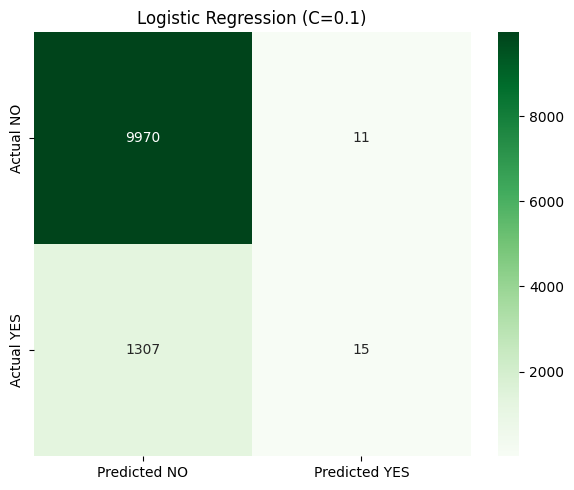

In [82]:
# confusion matrix
cm_log= confusion_matrix(y_test, y_pred_best)
cm_log

tn, fp, fn, tp = cm_log.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted NO', 'Predicted YES'],
            yticklabels=['Actual NO', 'Actual YES'])
plt.title(f'Logistic Regression (C={best_C})')
plt.tight_layout()
plt.show()

**PRECISION**: 57.7%
   <br>If you call 100 customers the model predicts will subscribe: 1) About 57 will actually subscribe; 2)About 43 calls are wasted

**RECALL**: 1.1%
   <br>Out of 100 actual subscribers in your database: 1)The model will find about 1 of them; 2)About 99 will be missed

**ACCURACY**: 88.3%
   <br>Overall, the model is correct 88% of the time

**CONFUSION MATRIX EXPLANATION**:
   <br>9970 customers correctly predicted as non-subscribers
   <br>11 customers predicted YES but actually said NO
   <br>1307 customers predicted NO but actually subscribed
   <br>15 customers correctly predicted as subscribers

**6.3 Random Forest Model**

In [83]:
# Random Forest creates multiple decision trees and averages their predictions
# random_state=42 ensures reproducible results
rf = RandomForestClassifier(random_state=42)

In [87]:
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)                    # Class predictions (0 or 1)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]  # Probability of subscribing

accuracy_rf=accuracy_score(y_test, y_pred_rf)
precision_rf=precision_score(y_test, y_pred_rf)
recall_rf=recall_score(y_test, y_pred_rf)

print(accuracy_rf,precision_rf,recall_rf)

0.8950721047509511 0.6566820276497696 0.21558245083207261


In [89]:
# try different random forest parameters

# Test different numbers of trees
n_estimators_list = [50, 100, 200]
results_rf = []

print("\nTesting different numbers of trees:")
print("-" * 60)
print(f"{'n_estimators':<15} {'Accuracy':<12} {'Precision':<12} {'Recall':<12}")
print("-" * 60)

for n in n_estimators_list:
    # Create and train Random Forest with current n_estimators
    rf_test = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_test.fit(X_train, y_train)
    y_pred_test = rf_test.predict(X_test)
    
    # Calculate metrics
    accuracy_rf = accuracy_score(y_test, y_pred_test)
    precision_rf = precision_score(y_test, y_pred_test)
    recall_rf = recall_score(y_test, y_pred_test)
    
    results_rf.append({
        'n_estimators': n,
        'accuracy': accuracy_rf,
        'precision': precision_rf,
        'recall': recall_rf,
        'model': rf_test
    })
    
    print(f"{n:<15} {accuracy_rf:<12.2%} {precision_rf:<12.2%} {recall_rf:<12.2%}")

print("-" * 60)

# Find best model based on accuracy
best_rf_result = max(results_rf, key=lambda x: x['accuracy'])
best_model = best_rf_result['model']
print(f"\n Best model: n_estimators={best_rf_result['n_estimators']} "
        )
print(f"accuracy_rf = {accuracy_rf:.2%}")
print(f" precision_rf = {precision_rf:.2%}")
print(f"recall_rf = {recall_rf:.2%}")


Testing different numbers of trees:
------------------------------------------------------------
n_estimators    Accuracy     Precision    Recall      
------------------------------------------------------------
50              89.44%       65.24%       20.73%      
100             89.51%       65.67%       21.56%      
200             89.43%       64.53%       21.33%      
------------------------------------------------------------

 Best model: n_estimators=100 
accuracy_rf = 89.43%
 precision_rf = 64.53%
recall_rf = 21.33%


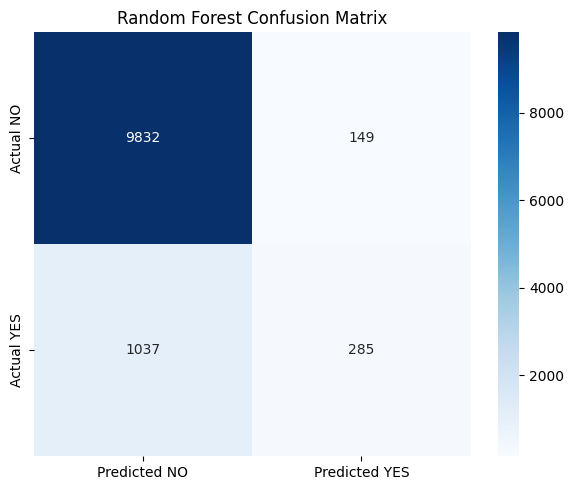

In [90]:
# confusion matrix
y_pred_best = best_model.predict(X_test)
cm_rf= confusion_matrix(y_test, y_pred_best)
cm_rf

tn, fp, fn, tp = cm_rf.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted NO', 'Predicted YES'],
            yticklabels=['Actual NO', 'Actual YES'])
plt.title(f'Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()

**PRECISION**: 64.53%
   <br>If you call 100 customers the model predicts will subscribe: 1) About 65 will actually subscribe; 2)About 35 calls are wasted

**RECALL**: 21.33%
   <br>Out of 100 actual subscribers in your database: 1)The model will find about 21 of them; 2)About 79 will be missed

**ACCURACY**: 89.43%
   <br>Overall, the model is correct 89% of the time

**CONFUSION MATRIX EXPLANATION**:
   <br>9832 customers correctly predicted as non-subscribers
   <br>149 customers predicted YES but actually said NO
   <br>1037 customers predicted NO but actually subscribed
   <br>285 customers correctly predicted as subscribers

**7.Model Comparisons**

### **Performance Metrics Summary**

| Model | Accuracy | Precision | Recall | F1-Score | Confusion Matrix (TN, FP, FN, TP) |
|-------|----------|-----------|--------|----------|-----------------------------------|
| KNN (k=9) | 89.11% | 61.46% | 18.46% | 28.39% | [[9828, 153], [1078, 244]] |
| Logistic Regression | 88.34% | 57.69% | 1.13% | 2.22% | [[9970, 11], [1307, 15]] |
| **Random Forest** | **89.51%** | **65.67%** | **21.56%** | **32.46%** | **[[9832, 149], [1037, 285]]** |

**Interpretation:**
- **True Negatives (TN)**: Correctly predicted non-subscribers
- **False Positives (FP)**: Wasted calls - predicted YES but actually NO
- **False Negatives (FN)**: Missed opportunities - predicted NO but actually YES
- **True Positives (TP)**: Correctly identified subscribers

**Final Recommendation**

Use **Random Forest** for bank marketing campaign because:

- **Best balance** of finding subscribers (recall) and avoiding waste (precision)
- **Highest accuracy** overall
- **Feature importance** capability (can tell you WHY customers subscribe)
- **No scaling required** (unlike KNN)
- **Handles non-linear relationships** better than Logistic Regression

**Business Strategy with Random Forest**

1. **Target the top 20%** of customers with highest predicted probability
2. Expected outcome per 100 calls: **66 subscribers**
3. Expected to find **22% of all potential subscribers**
4. Can improve by collecting more data on current subscribers